# AMR Drug Repurposing — 02: Modeling

Trains Random Forest and deep MLP on ECFP4 fingerprints, evaluates both, screens FDA-approved drugs, computes SHAP attributions, and optionally fine-tunes ChemBERTa.

## Paths

In [2]:
from pathlib import Path
import os

PROJECT_ROOT = Path(__file__).resolve().parents[1] if '__file__' in dir() else Path.cwd().parent
# When running from notebooks/ dir, parent is the project root
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path.cwd()

DATA_DIR  = PROJECT_ROOT / 'data'
CKPT_DIR  = PROJECT_ROOT / 'checkpoints'
FIG_DIR   = PROJECT_ROOT / 'figures'

for d in [DATA_DIR, CKPT_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR}")
print(f"CKPT_DIR     : {CKPT_DIR}")
print(f"FIG_DIR      : {FIG_DIR}")

PROJECT_ROOT : /Users/jubayer/Projects/amr_drug_repurposing
DATA_DIR     : /Users/jubayer/Projects/amr_drug_repurposing/data
CKPT_DIR     : /Users/jubayer/Projects/amr_drug_repurposing/checkpoints
FIG_DIR      : /Users/jubayer/Projects/amr_drug_repurposing/figures


## Imports

In [3]:
import asyncio, httpx, json, time, warnings, os
import nest_asyncio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings('ignore')
nest_asyncio.apply()

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: mps


## Load pre-computed fingerprints

In [4]:
X = np.load(DATA_DIR / 'X_ecfp.npy')
y = np.load(DATA_DIR / 'y_labels.npy')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")

Train: 57,298 | Test: 14,325
Train positive rate: 0.431
Test  positive rate: 0.431


## Random Forest baseline

In [5]:
print("Training Random Forest...")
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight='balanced', n_jobs=-1, random_state=SEED
)
rf.fit(X_train, y_train)

rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)

rf_roc = roc_auc_score(y_test, rf_prob)
rf_prc = average_precision_score(y_test, rf_prob)

print(f"RF done ({time.time()-t0:.0f}s)")
print(f"ROC-AUC: {rf_roc:.4f}  |  PRC-AUC: {rf_prc:.4f}")
print(classification_report(y_test, rf_pred, target_names=['Inactive','Active']))

baseline_results = {'roc_auc': rf_roc, 'prc_auc': rf_prc}

Training Random Forest...
RF done (10s)
ROC-AUC: 0.9162  |  PRC-AUC: 0.8917
              precision    recall  f1-score   support

    Inactive       0.85      0.86      0.86      8146
      Active       0.81      0.81      0.81      6179

    accuracy                           0.84     14325
   macro avg       0.83      0.83      0.83     14325
weighted avg       0.84      0.84      0.84     14325



## Deep MLP architecture

In [6]:
class FingerprintDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


class AntibacterialMLP(nn.Module):
    def __init__(self, input_dim=2048, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(1024, 512),       nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),        nn.BatchNorm1d(256),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),        nn.BatchNorm1d(128),  nn.ReLU(), nn.Dropout(dropout * 0.5),
            nn.Linear(128, 1),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x).squeeze(-1)


n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
pos_weight   = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)

sample_weights = np.where(y_train == 1, n_neg / n_pos, 1.0)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(y_train), replacement=True)

BATCH_SIZE = 256
train_loader = DataLoader(FingerprintDataset(X_train, y_train), batch_size=BATCH_SIZE, sampler=sampler)
test_loader  = DataLoader(FingerprintDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

model     = AntibacterialMLP(input_dim=X_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 2,791,169


## Training loop with checkpointing

In [7]:
CKPT_PATH = CKPT_DIR / 'best_mlp.pt'
EPOCHS, LOG_EVERY = 60, 5

def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            logits = model(X_b.to(device)).cpu()
            all_logits.append(logits)
            all_labels.append(y_b)
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    proba  = 1 / (1 + np.exp(-logits))
    return roc_auc_score(labels, proba), average_precision_score(labels, proba)

# Resume from checkpoint if available
start_epoch, best_auc = 0, 0.0
if CKPT_PATH.exists():
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch = ckpt['epoch'] + 1
    best_auc    = ckpt['best_auc']
    print(f"Resumed from epoch {ckpt['epoch']} | best ROC-AUC: {best_auc:.4f}")

train_losses, val_aucs, val_prcs = [], [], []

print(f"Training on {device} for {EPOCHS} epochs...")
for epoch in range(start_epoch, EPOCHS):
    model.train()
    epoch_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    roc, prc = evaluate(model, test_loader)
    val_aucs.append(roc)
    val_prcs.append(prc)

    if roc > best_auc:
        best_auc = roc
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'best_auc': best_auc}, CKPT_PATH)
        marker = " ← best"
    else:
        marker = ""

    if (epoch + 1) % LOG_EVERY == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | "
              f"ROC-AUC: {roc:.4f} | PRC-AUC: {prc:.4f}{marker}")

print(f"\nBest ROC-AUC: {best_auc:.4f}")

Resumed from epoch 19 | best ROC-AUC: 0.9131
Training on mps for 60 epochs...
Epoch  25/60 | Loss: 0.1830 | ROC-AUC: 0.9100 | PRC-AUC: 0.8856
Epoch  30/60 | Loss: 0.1724 | ROC-AUC: 0.9092 | PRC-AUC: 0.8844
Epoch  35/60 | Loss: 0.1648 | ROC-AUC: 0.9082 | PRC-AUC: 0.8831
Epoch  40/60 | Loss: 0.1535 | ROC-AUC: 0.9090 | PRC-AUC: 0.8848
Epoch  45/60 | Loss: 0.1505 | ROC-AUC: 0.9086 | PRC-AUC: 0.8840
Epoch  50/60 | Loss: 0.1459 | ROC-AUC: 0.9091 | PRC-AUC: 0.8844
Epoch  55/60 | Loss: 0.1400 | ROC-AUC: 0.9083 | PRC-AUC: 0.8840
Epoch  60/60 | Loss: 0.1368 | ROC-AUC: 0.9078 | PRC-AUC: 0.8837

Best ROC-AUC: 0.9131


## Training curves

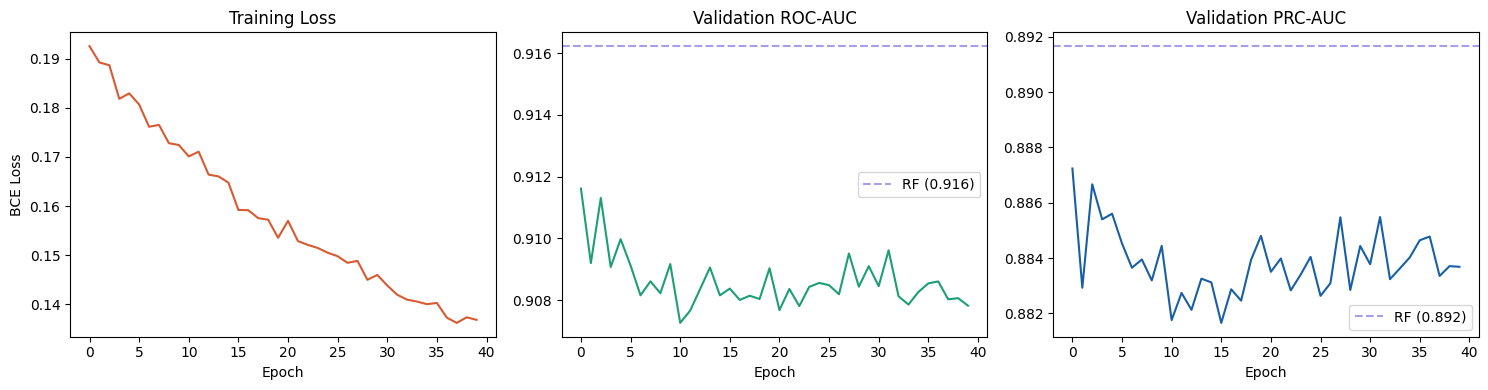

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_losses, color='#D85A30', lw=1.5)
axes[0].set(title='Training Loss', xlabel='Epoch', ylabel='BCE Loss')

axes[1].plot(val_aucs, color='#1D9E75', lw=1.5)
axes[1].axhline(baseline_results['roc_auc'], color='#7F77DD', ls='--', alpha=0.7,
                label=f"RF ({baseline_results['roc_auc']:.3f})")
axes[1].set(title='Validation ROC-AUC', xlabel='Epoch')
axes[1].legend()

axes[2].plot(val_prcs, color='#185FA5', lw=1.5)
axes[2].axhline(baseline_results['prc_auc'], color='#7F77DD', ls='--', alpha=0.7,
                label=f"RF ({baseline_results['prc_auc']:.3f})")
axes[2].set(title='Validation PRC-AUC', xlabel='Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'training_curves.png', dpi=150)
plt.show()

## Final evaluation on test set

In [9]:
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

all_proba, all_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        logits = model(X_b.to(device)).cpu().numpy()
        all_proba.extend(1 / (1 + np.exp(-logits)))
        all_labels.extend(y_b.numpy())

y_prob = np.array(all_proba)
y_true = np.array(all_labels)
y_pred = (y_prob >= 0.5).astype(int)

mlp_roc = roc_auc_score(y_true, y_prob)
mlp_prc = average_precision_score(y_true, y_prob)

print(f"MLP  ROC-AUC: {mlp_roc:.4f}  |  PRC-AUC: {mlp_prc:.4f}")
print(classification_report(y_true, y_pred, target_names=['Inactive','Active']))

MLP  ROC-AUC: 0.9131  |  PRC-AUC: 0.8891
              precision    recall  f1-score   support

    Inactive       0.87      0.82      0.85      8146
      Active       0.78      0.84      0.81      6179

    accuracy                           0.83     14325
   macro avg       0.83      0.83      0.83     14325
weighted avg       0.83      0.83      0.83     14325



## ROC, PR curves, and confusion matrix

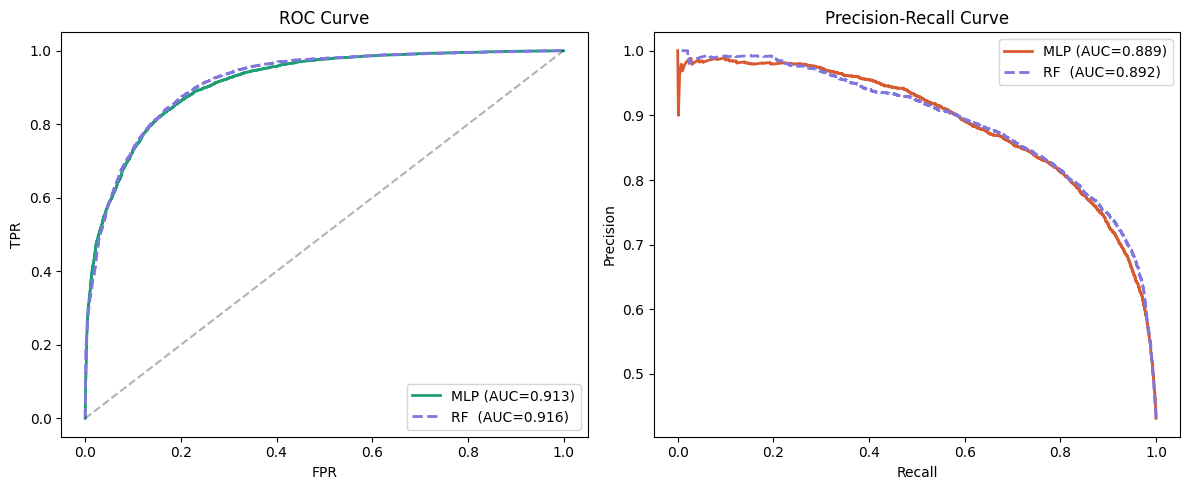

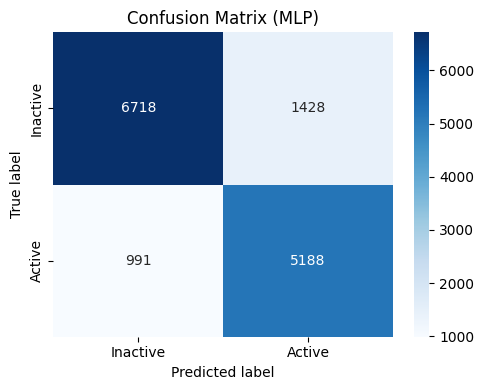

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_true, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])
axes[0].plot(fpr,    tpr,    color='#1D9E75', lw=2, label=f'MLP (AUC={mlp_roc:.3f})')
axes[0].plot(fpr_rf, tpr_rf, color='#7F77DD', lw=2, ls='--',
             label=f'RF  (AUC={roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_true, y_prob)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf.predict_proba(X_test)[:, 1])
axes[1].plot(rec,    prec,    color='#D85A30', lw=2, label=f'MLP (AUC={mlp_prc:.3f})')
axes[1].plot(rec_rf, prec_rf, color='#7F77DD', lw=2, ls='--',
             label=f'RF  (AUC={average_precision_score(y_test, rf.predict_proba(X_test)[:,1]):.3f})')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'evaluation_curves.png', dpi=150)
plt.show()

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'])
ax.set(title='Confusion Matrix (MLP)', ylabel='True label', xlabel='Predicted label')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## Fetch FDA-approved drugs for repurposing screen

In [11]:
BASE_URL = "https://www.ebi.ac.uk/chembl/api/data"

async def fetch_page(client, url, params, retries=3):
    for attempt in range(retries):
        try:
            r = await client.get(url, params=params, timeout=60)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            if attempt == retries - 1:
                print(f"Failed: {e}")
                return None
            await asyncio.sleep(2 ** attempt)

async def fetch_approved_drugs():
    params = {
        "max_phase": 4,
        "molecule_type": "Small molecule",
        "limit": 1000, "offset": 0, "format": "json",
        "fields": "molecule_chembl_id,pref_name,max_phase,molecule_structures,indication_class",
    }
    records = []
    async with httpx.AsyncClient() as client:
        data = await fetch_page(client, f"{BASE_URL}/molecule.json", params)
        total = data["page_meta"]["total_count"]
        records.extend(data["molecules"])
        print(f"Total approved drugs: {total}")
        tasks = [fetch_page(client, f"{BASE_URL}/molecule.json", {**params, "offset": o})
                 for o in range(1000, total, 1000)]
        for p in await asyncio.gather(*tasks):
            if p:
                records.extend(p["molecules"])
    return records

APPROVED_PATH = DATA_DIR / 'approved_drugs.csv'

if APPROVED_PATH.exists() and APPROVED_PATH.stat().st_size > 0:
    df_drugs = pd.read_csv(APPROVED_PATH)
    if 'canonical_smiles' not in df_drugs.columns:
        df_drugs = pd.DataFrame()
    else:
        print(f"Loaded {len(df_drugs)} approved drugs from cache")
else:
    df_drugs = pd.DataFrame()

if df_drugs.empty:
    records  = await fetch_approved_drugs()
    df_drugs = pd.DataFrame(records)
    if 'molecule_structures' in df_drugs.columns:
        df_drugs['canonical_smiles'] = df_drugs['molecule_structures'].apply(
            lambda x: x.get('canonical_smiles') if isinstance(x, dict) else None
        )
    df_drugs.to_csv(APPROVED_PATH, index=False)

if 'indication_class' not in df_drugs.columns:
    df_drugs['indication_class'] = ""

df_drugs = df_drugs.dropna(subset=['canonical_smiles'])
df_drugs = df_drugs[df_drugs['canonical_smiles'].str.len() > 5]

antibiotic_kw = ['antibiotic','antibacterial','antimicrobial','beta-lactam',
                  'penicillin','cephalosporin','macrolide','quinolone','aminoglycoside']
antibiotic_mask = df_drugs['indication_class'].fillna('').str.lower().apply(
    lambda x: any(kw in x for kw in antibiotic_kw)
)
df_drugs_nonabx = df_drugs[~antibiotic_mask].copy()
print(f"Approved non-antibiotic drugs: {len(df_drugs_nonabx)}")

Loaded 3280 approved drugs from cache
Approved non-antibiotic drugs: 3112


## Repurposing screen

In [12]:
def smiles_to_ecfp(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits)
    return np.array(fp)

print("Generating fingerprints for approved drugs...")
screen_fps, screen_ids, screen_names, screen_smiles, screen_ind = [], [], [], [], []

for _, row in tqdm(df_drugs_nonabx.iterrows(), total=len(df_drugs_nonabx)):
    fp = smiles_to_ecfp(row['canonical_smiles'])
    if fp is not None:
        screen_fps.append(fp)
        screen_ids.append(row['molecule_chembl_id'])
        screen_names.append(row.get('pref_name', 'Unknown'))
        screen_smiles.append(row['canonical_smiles'])
        screen_ind.append(row.get('indication_class', ''))

X_screen = np.array(screen_fps, dtype=np.float32)

model.eval()
screen_probs = []
with torch.no_grad():
    for batch in DataLoader(torch.tensor(X_screen), batch_size=512, shuffle=False):
        logits = model(batch.to(device)).cpu().numpy()
        screen_probs.extend(1 / (1 + np.exp(-logits)))

rf_probs       = rf.predict_proba(X_screen)[:, 1]
ensemble_probs = (np.array(screen_probs) + rf_probs) / 2

df_results = pd.DataFrame({
    'chembl_id':     screen_ids,
    'drug_name':     screen_names,
    'smiles':        screen_smiles,
    'indication':    screen_ind,
    'prob_mlp':      np.round(screen_probs, 4),
    'prob_rf':       np.round(rf_probs, 4),
    'prob_ensemble': np.round(ensemble_probs, 4),
}).sort_values('prob_ensemble', ascending=False)

df_results.to_csv(DATA_DIR / 'repurposing_candidates.csv', index=False)
print(df_results[['drug_name','indication','prob_ensemble','prob_mlp','prob_rf']].head(20).to_string(index=False))

Generating fingerprints for approved drugs...


  0%|          | 0/3112 [00:00<?, ?it/s]

                  drug_name indication  prob_ensemble  prob_mlp  prob_rf
               SPARFLOXACIN                    0.9998    1.0000   0.9996
               TEMAFLOXACIN                    0.9994    1.0000   0.9989
 TEMAFLOXACIN HYDROCHLORIDE                    0.9987    1.0000   0.9974
              GREPAFLOXACIN                    0.9986    1.0000   0.9971
GREPAFLOXACIN HYDROCHLORIDE                    0.9985    1.0000   0.9970
     LEVOFLOXACIN ANHYDROUS                    0.9979    0.9991   0.9966
                  OFLOXACIN                    0.9979    0.9991   0.9966
               GATIFLOXACIN                    0.9978    0.9996   0.9961
               LEVOFLOXACIN                    0.9973    0.9991   0.9956
              CIPROFLOXACIN                    0.9969    0.9997   0.9941
               MOXIFLOXACIN                    0.9967    0.9984   0.9949
 MOXIFLOXACIN HYDROCHLORIDE                    0.9966    0.9991   0.9940
CIPROFLOXACIN HYDROCHLORIDE                    0.99

## Visualise top candidates

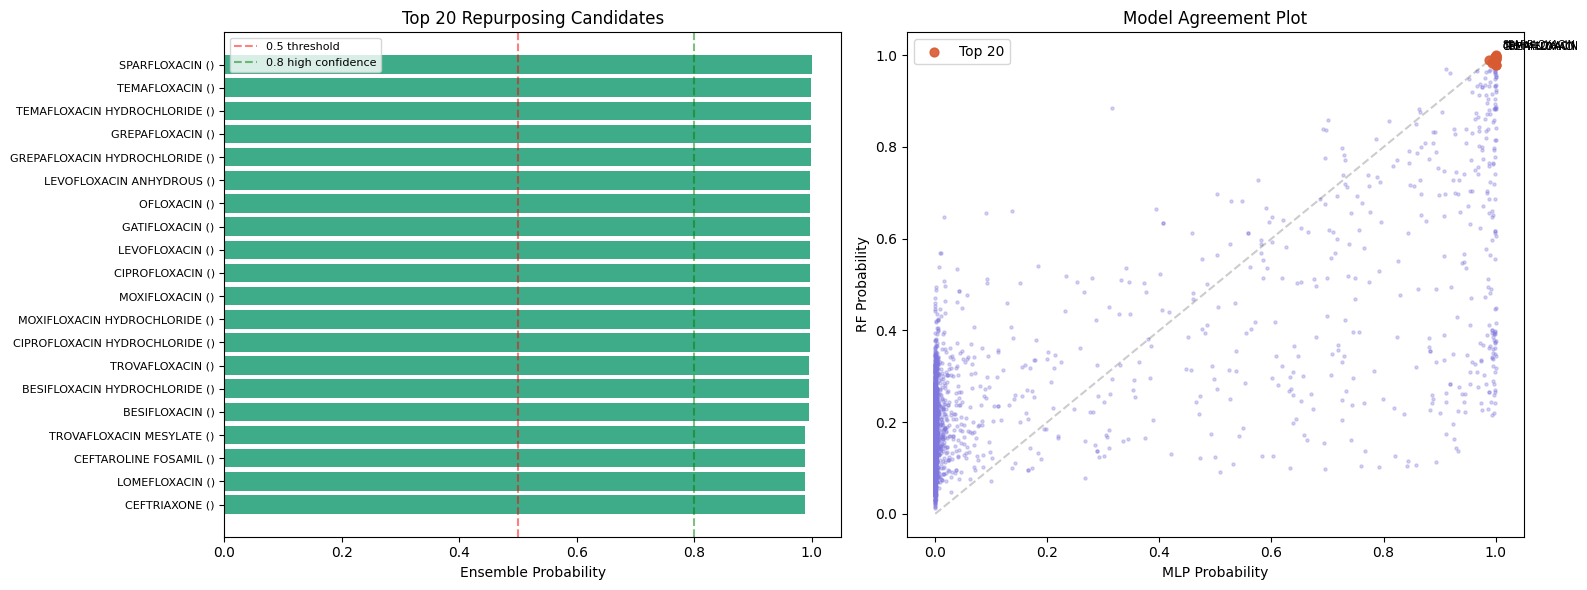

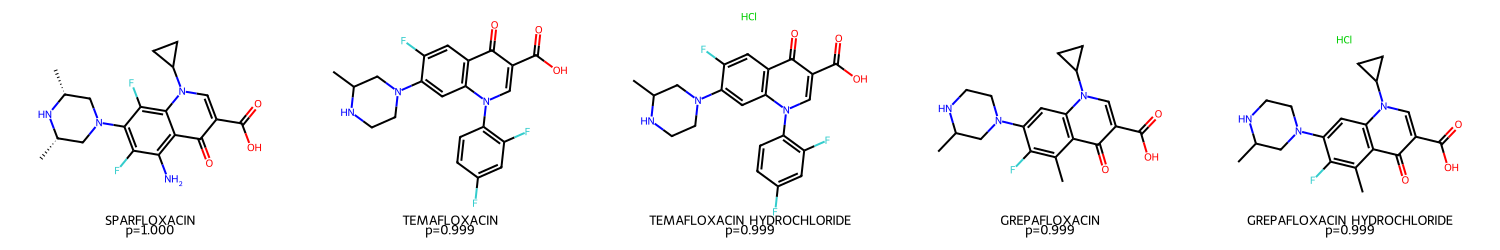

In [13]:
top20 = df_results.head(20).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#1D9E75' if p >= 0.8 else '#EF9F27' if p >= 0.6 else '#185FA5'
          for p in top20['prob_ensemble']]
axes[0].barh(range(len(top20)), top20['prob_ensemble'], color=colors, alpha=0.85)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels([f"{n} ({i})" for n, i in
                          zip(top20['drug_name'], top20['indication'].fillna('—').str[:25])],
                         fontsize=8)
axes[0].axvline(0.5, color='red',   ls='--', alpha=0.5, label='0.5 threshold')
axes[0].axvline(0.8, color='green', ls='--', alpha=0.5, label='0.8 high confidence')
axes[0].set_xlabel('Ensemble Probability')
axes[0].set_title('Top 20 Repurposing Candidates')
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

axes[1].scatter(df_results['prob_mlp'], df_results['prob_rf'], alpha=0.3, s=5, color='#7F77DD')
axes[1].scatter(top20['prob_mlp'],     top20['prob_rf'],       alpha=0.9, s=40, color='#D85A30',
                label='Top 20', zorder=5)
for _, row in top20.head(5).iterrows():
    axes[1].annotate(str(row['drug_name'])[:12], (row['prob_mlp'], row['prob_rf']),
                     fontsize=7, xytext=(5,5), textcoords='offset points')
axes[1].set(xlabel='MLP Probability', ylabel='RF Probability', title='Model Agreement Plot')
axes[1].legend()
axes[1].plot([0,1],[0,1],'k--', alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'repurposing_candidates.png', dpi=150)
plt.show()

top5_smiles = top20['smiles'].head(5).tolist()
top5_names  = top20['drug_name'].head(5).tolist()
mols = [m for s in top5_smiles if (m := Chem.MolFromSmiles(s)) is not None]
if mols:
    img = Draw.MolsToGridImage(
        mols[:5], molsPerRow=5, subImgSize=(300, 250), useSVG=False,
        legends=[f"{n}\np={p:.3f}" for n, p in zip(top5_names, top20['prob_ensemble'].head(5))]
    )
    if hasattr(img, 'save'):
        img.save(str(FIG_DIR / 'top5_structures.png'))
    from IPython.display import display
    display(img)

## SHAP feature importance

Computing SHAP values on RF...


100%|===================| 996/1000 [02:34<00:00]        

<Figure size 1000x600 with 0 Axes>

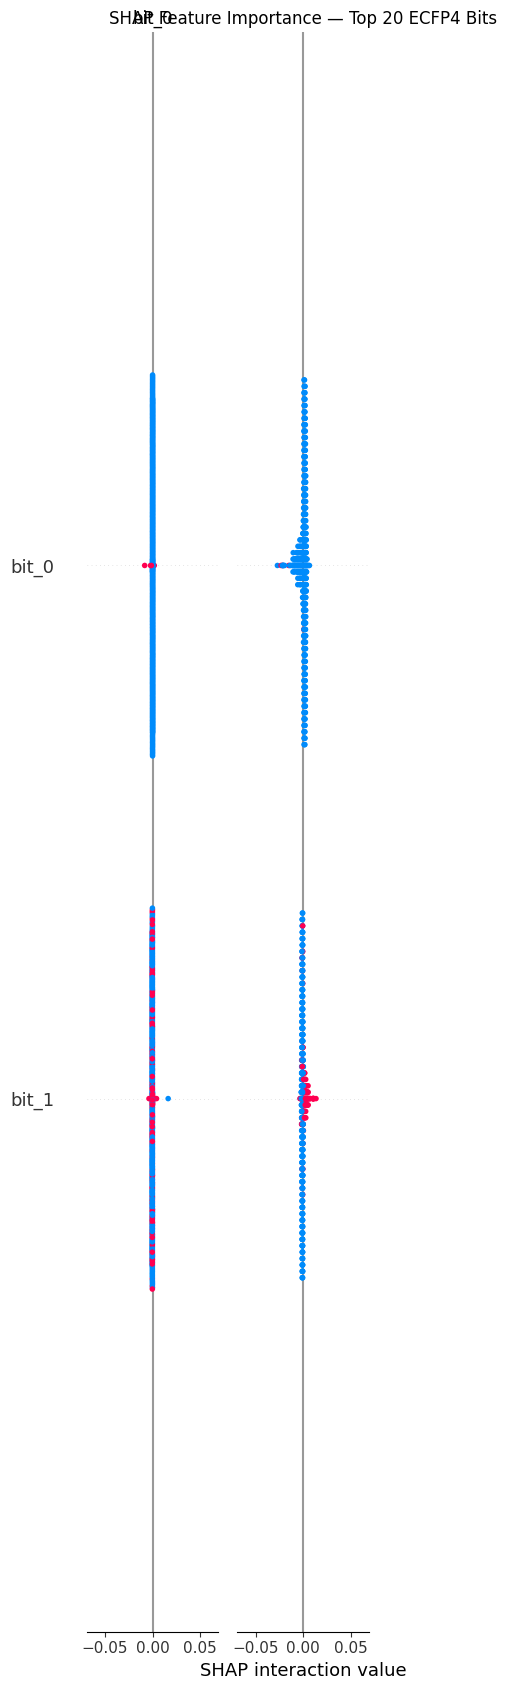

In [14]:
import shap

print("Computing SHAP values on RF...")
background = shap.sample(X_train, 500, random_state=SEED)
explainer  = shap.TreeExplainer(rf, background)
X_explain  = X_test[:500]
shap_vals  = explainer.shap_values(X_explain)

sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_explain,
                  feature_names=[f"bit_{i}" for i in range(X_train.shape[1])],
                  max_display=20, show=False)
plt.title("SHAP Feature Importance — Top 20 ECFP4 Bits")
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## ChemBERTa fine-tuning

Requires GPU. On Apple Silicon MPS is used but ChemBERTa fp16 needs MPS >= macOS 14.

In [4]:
if device.type == 'cpu':
    print("No GPU/MPS detected — skipping ChemBERTa fine-tuning. MLP results are sufficient.")
else:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                               TrainingArguments, Trainer, EarlyStoppingCallback)
    from datasets import Dataset as HFDataset

    MODEL_NAME = "seyonec/ChemBERTa-zinc-base-v1"
    tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

    smiles_arr = np.load(DATA_DIR / 'smiles_valid.npy', allow_pickle=True)
    labels_arr = np.load(DATA_DIR / 'y_labels.npy')
    smi_tr, smi_te, y_tr, y_te = train_test_split(
        smiles_arr, labels_arr, test_size=0.2, random_state=SEED, stratify=labels_arr
    )
    def tokenize(batch):
        return tokenizer(list(batch['smiles']), truncation=True, padding='max_length', max_length=128)

    train_hf = HFDataset.from_dict({'smiles': smi_tr, 'label': y_tr.tolist()}).map(tokenize, batched=True)
    test_hf  = HFDataset.from_dict({'smiles': smi_te, 'label': y_te.tolist()}).map(tokenize, batched=True)

    bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    use_fp16 = (device.type == 'cuda')
    args = TrainingArguments(
        output_dir=str(CKPT_DIR / 'chembert'),
        num_train_epochs=10,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5, weight_decay=0.01,
        eval_strategy='epoch', save_strategy='epoch',
        load_best_model_at_end=True, metric_for_best_model='eval_loss',
        fp16=use_fp16, gradient_checkpointing=True,
        logging_steps=50, report_to='none',
    )
    trainer = Trainer(
        model=bert_model, args=args,
        train_dataset=train_hf, eval_dataset=test_hf,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    trainer.train()
    print("ChemBERTa fine-tuning complete.")

Map:   0%|          | 0/57298 [00:00<?, ? examples/s]

Map:   0%|          | 0/14325 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream t

Epoch,Training Loss,Validation Loss
1,0.481243,0.452215
2,0.410358,0.438593
3,0.359152,0.436425
4,0.350220,0.429921
5,0.366748,0.428759
6,0.304812,0.446747
7,0.268090,0.469784
8,0.297032,0.484648


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

ChemBERTa fine-tuning complete.
